# FIFA World Cup 2026 — Vancouver Transit Stress Simulation
### Scenario-based risk modeling + explainable ML decision-support

**This is NOT a ridership forecast.** It is a *scenario stress simulation* layered
on top of an already-built reliability engine. Every risk number traces back to a
transparent formula you can read and challenge.

---

## 1. Project framing

The backend (Python + DuckDB) already produced, for the **Top 20 highest-activity
corridors**:

- observed bus spacing → bunching events → severity classification
- per-route reliability scores and bands
- corridor intervention-priority ranking
- bunching hotspots with human-readable stop names
- hourly / peak-period bunching patterns

This notebook asks a forward-looking question the backend does not:

> *When FIFA World Cup 2026 stresses the network, which of these corridors are most
> likely to degrade, and where should TransLink-style monitoring be concentrated?*

**Event context (treated as configurable assumptions, not facts):**

- Vancouver / BC Place hosts **7 FIFA matches**.
- **FIFA Fan Festival** at Hastings Park / PNE.
- TransLink announced **~600 extra bus trips/day** during the tournament.
- Extra service expected around Hastings Park/PNE incl. **R5, 14, 28, 130, 222**
  and a dedicated Fan Festival shuttle.

**Two-layer design:**

1. **Scenario model (primary).** Deterministic, auditable. Baseline reliability is
   adjusted by an *explainable stress multiplier* built from exposure tags.
2. **ML layer (supporting).** Logistic Regression + Random Forest trained on the
   scenario output. Its job is **explainability and validation** — feature
   importance, sensitivity, and catching routes where a non-linear model disagrees
   with the linear score. It is **not** an independent forecast.

> ⚠️ **Honesty guardrail.** The ML model is trained on labels we ourselves defined.
> It therefore cannot validate the *truth* of FIFA risk — only the *internal
> consistency* of our scenario scoring. True validation needs real matchday AVL
> telemetry, passenger counts, and crowd-movement data we do not have.

## 2. Load baseline Top 20 reliability outputs

We read the existing engine outputs. Paths assume the CSVs sit next to the notebook;
adjust `DATA_DIR` if yours live in `reports/sql_outputs/`.

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)

# --- where the baseline CSVs live ---
DATA_DIR = Path(".")          # e.g. Path("reports/sql_outputs")
OUT_DIR  = Path("fifa_outputs")
OUT_DIR.mkdir(exist_ok=True)

def load(name, required=True):
    p = DATA_DIR / name
    if not p.exists():
        if required:
            raise FileNotFoundError(f"Missing required baseline file: {p}")
        print(f"[optional] not found, skipping: {name}")
        return None
    df = pd.read_csv(p)
    print(f"loaded {name:<48} {df.shape}")
    return df

reliability = load("top20_route_reliability_scores.csv")
priority    = load("top20_corridor_priority_ranking.csv")
type_summ   = load("top20_route_type_summary.csv")
hotspots    = load("top20_bunching_hotspots_with_stops.csv")
hourly      = load("top20_hourly_bunching_pattern.csv")

# optional
events      = load("top20_bunching_events.csv",   required=False)
hotspots_no = load("top20_bunching_hotspots.csv", required=False)


loaded top20_route_reliability_scores.csv               (20, 14)
loaded top20_corridor_priority_ranking.csv              (20, 16)
loaded top20_route_type_summary.csv                     (4, 10)
loaded top20_bunching_hotspots_with_stops.csv           (948, 24)
loaded top20_hourly_bunching_pattern.csv                (190, 13)
loaded top20_bunching_events.csv                        (9656, 16)
loaded top20_bunching_hotspots.csv                      (948, 16)


## 3. Data quality checks

Before modeling, confirm the baseline is internally consistent: 20 routes, no
duplicate route_ids, reliability scores in range, rates non-negative. The corridor
priority file is our master table (it has intervention scores and worst-segment
counts), so we anchor on it.

In [2]:
def quality_report(df, name, key="route_id"):
    print(f"\n=== {name} ===")
    print(f"rows={len(df)}  cols={df.shape[1]}")
    if key in df.columns:
        dups = df[key].duplicated().sum()
        print(f"duplicate {key}: {dups}")
    nulls = df.isna().sum()
    nulls = nulls[nulls > 0]
    print("nulls:", dict(nulls) if len(nulls) else "none")

quality_report(priority, "corridor_priority_ranking")
quality_report(reliability, "route_reliability_scores")

# sanity ranges on the master table
assert priority["reliability_score"].between(0, 100).all(), "reliability out of range"
assert (priority["bunching_rate_pct"] >= 0).all(), "negative bunching rate"
assert priority["route_id"].is_unique, "route_id not unique"
print(f"\nRoute types present: {sorted(priority['route_type'].unique())}")
print(f"Routes: {priority['route_short_name'].tolist()}")
print("\nData quality checks passed.")



=== corridor_priority_ranking ===
rows=20  cols=16
duplicate route_id: 0
nulls: none

=== route_reliability_scores ===
rows=20  cols=14
duplicate route_id: 0
nulls: none

Route types present: ['B-Line', 'Express / Regional', 'RapidBus', 'Regular Bus']
Routes: ['R4', '004', '099', '019', '016', '007', '014', '100', '410', '020', '025', '049', '009', '250', '335', '160', '321', '503', 'R5', '502']

Data quality checks passed.


## 4. Define FIFA scenario assumptions

**Everything FIFA-specific lives in this one config block.** Change a number here and
the entire downstream analysis updates. Nothing about FIFA is hard-coded deeper in
the notebook — that is what "configurable scenario inputs, not hard-coded truth"
means in practice.

The multipliers below are *planning assumptions*, deliberately round and
conservative. They encode beliefs like "a downtown/BC Place corridor on a PM-peak
matchday sees materially more stress than a suburban express off-peak" — not measured
demand.

In [3]:
# ------------------------------------------------------------------
# FIFA SCENARIO CONFIG  (the single source of FIFA assumptions)
# ------------------------------------------------------------------
FIFA = {
    # --- exposure weights: how much each exposure type adds to stress ---
    # expressed as fractional uplift to the stress multiplier (0.20 = +20%)
    "w_bc_place":        0.30,   # serves BC Place / stadium movement
    "w_downtown":        0.20,   # serves downtown core congestion
    "w_fan_festival":    0.25,   # serves Hastings Park / PNE fan festival
    "w_skytrain_conn":   0.10,   # feeds a SkyTrain station (transfer surge)
    "w_pm_peak_vuln":    0.15,   # already concentrates bunching in peaks
    "w_reliability_weak":0.20,   # already fragile before any FIFA load

    # --- scenario-level demand pressure (global multiplier per scenario) ---
    "scenario_pressure": {
        "normal_day":            0.00,   # baseline, no event
        "fifa_offpeak_match":    0.25,   # match, but not during commute peak
        "fifa_pmpeak_match":     0.55,   # match overlapping PM commute peak
        "fifa_knockout_match":   0.80,   # high-demand knockout / festival overlap
    },

    # --- extra-service relief assumption ---
    # TransLink's ~600 extra trips/day partially offset stress on served routes.
    "extra_service_relief": 0.15,   # routes with announced extra service get -15%

    # --- routes named in TransLink's extra-service announcement ---
    "extra_service_routes": ["R5", "014", "028", "130", "222"],

    # --- risk band cut points on the FIFA stress score (0-100ish) ---
    "risk_bands": [(0, 25, "Low"), (25, 45, "Medium"),
                   (45, 65, "High"), (65, 999, "Critical")],

    # --- ML high-risk label threshold (on fifa_stress_score) ---
    "ml_high_risk_threshold": 45.0,
}

# cap on the total multiplier so no route explodes unrealistically
MULTIPLIER_CAP = 2.5

print("FIFA scenario config loaded. Exposure weights:")
for k, v in FIFA.items():
    if k.startswith("w_"):
        print(f"  {k:<22} +{v:.0%}")


FIFA scenario config loaded. Exposure weights:
  w_bc_place             +30%
  w_downtown             +20%
  w_fan_festival         +25%
  w_skytrain_conn        +10%
  w_pm_peak_vuln         +15%
  w_reliability_weak     +20%


## 5. Create route exposure tags

Exposure tags convert geography and behavior into 0/1 (or 0–1) flags the stress
formula can use. Two honest caveats:

- **Venue/festival exposure is assigned by route knowledge**, not by geometry. We map
  the well-known Vancouver corridors. This is editable and should be reviewed by
  someone with local network knowledge.
- **PM-peak vulnerability and reliability weakness are data-driven** — derived from
  your actual baseline (`peak_bunching_share_pct`, `reliability_score`), not guessed.

We start from the corridor priority table and attach tags to it.

In [4]:
df = priority.copy()
df["route_short_name"] = df["route_short_name"].astype(str)

# ------------------------------------------------------------------
# 5a. Venue / geography exposure  (route-knowledge based, editable)
# ------------------------------------------------------------------
# BC Place / downtown core corridors (serve or terminate downtown)
BC_PLACE_ROUTES   = {"R4", "099", "009", "014", "004", "007", "016", "019", "100"}
DOWNTOWN_ROUTES   = {"099", "009", "014", "004", "007", "R5", "019", "100"}
# Fan Festival = Hastings Park / PNE corridor
FAN_FEST_ROUTES   = {"R5", "014"}              # Hastings St corridor to PNE
# SkyTrain connector = route name references a Station
def is_skytrain_connector(name):
    return int("Station" in str(name))

df["bc_place_exposure"]     = df["route_short_name"].isin(BC_PLACE_ROUTES).astype(int)
df["downtown_exposure"]     = df["route_short_name"].isin(DOWNTOWN_ROUTES).astype(int)
df["fan_festival_exposure"] = df["route_short_name"].isin(FAN_FEST_ROUTES).astype(int)
df["skytrain_connector_exposure"] = df["route_long_name"].apply(is_skytrain_connector)

# ------------------------------------------------------------------
# 5b. Data-driven vulnerability tags  (from YOUR baseline)
# ------------------------------------------------------------------
# PM peak vulnerability: high share of bunching concentrated in peaks.
# (peak_bunching_share_pct is AM+PM peak share; high share => peak-fragile.)
peak_thresh = df["peak_bunching_share_pct"].median()
df["pm_peak_vulnerability"] = (df["peak_bunching_share_pct"] >= peak_thresh).astype(int)

# Existing reliability weakness: below-median reliability score = already fragile.
rel_thresh = df["reliability_score"].median()
df["existing_reliability_weakness"] = (df["reliability_score"] < rel_thresh).astype(int)

# extra-service relief flag (from announcement)
df["has_extra_service"] = df["route_short_name"].isin(FIFA["extra_service_routes"]).astype(int)

tag_cols = ["bc_place_exposure","downtown_exposure","fan_festival_exposure",
            "skytrain_connector_exposure","pm_peak_vulnerability",
            "existing_reliability_weakness","has_extra_service"]
print(df[["route_short_name","route_type","reliability_score"]+tag_cols].to_string(index=False))


route_short_name         route_type  reliability_score  bc_place_exposure  downtown_exposure  fan_festival_exposure  skytrain_connector_exposure  pm_peak_vulnerability  existing_reliability_weakness  has_extra_service
              R4           RapidBus              77.60                  1                  0                      0                            0                      0                              1                  0
             004        Regular Bus              81.95                  1                  1                      0                            0                      1                              1                  0
             099             B-Line              84.21                  1                  1                      0                            0                      0                              1                  0
             019        Regular Bus              85.41                  1                  1                      0             

## 6. Build the explainable FIFA stress multiplier

The multiplier is a plain weighted sum of exposure flags — fully transparent:

```
exposure_uplift =  w_bc_place      * bc_place_exposure
                +  w_downtown      * downtown_exposure
                +  w_fan_festival  * fan_festival_exposure
                +  w_skytrain_conn * skytrain_connector_exposure
                +  w_pm_peak_vuln  * pm_peak_vulnerability
                +  w_reliability_weak * existing_reliability_weakness

stress_multiplier = 1 + exposure_uplift          (then capped)
```

A route with zero exposure has multiplier `1.0` (FIFA changes nothing for it). A
downtown, festival-adjacent, already-fragile route stacks several uplifts. The cap
prevents any single route from running away.

In [5]:
def exposure_uplift(row):
    return (
        FIFA["w_bc_place"]         * row["bc_place_exposure"]
      + FIFA["w_downtown"]         * row["downtown_exposure"]
      + FIFA["w_fan_festival"]     * row["fan_festival_exposure"]
      + FIFA["w_skytrain_conn"]    * row["skytrain_connector_exposure"]
      + FIFA["w_pm_peak_vuln"]     * row["pm_peak_vulnerability"]
      + FIFA["w_reliability_weak"] * row["existing_reliability_weakness"]
    )

df["exposure_uplift"]    = df.apply(exposure_uplift, axis=1)
df["stress_multiplier"]  = (1 + df["exposure_uplift"]).clip(upper=MULTIPLIER_CAP)

print(df[["route_short_name","exposure_uplift","stress_multiplier"]]
      .sort_values("stress_multiplier", ascending=False).to_string(index=False))


route_short_name  exposure_uplift  stress_multiplier
             014             1.10               2.10
             007             0.95               1.95
             004             0.85               1.85
             100             0.85               1.85
             009             0.85               1.85
             099             0.70               1.70
             019             0.70               1.70
             016             0.60               1.60
              R4             0.50               1.50
              R5             0.45               1.45
             049             0.35               1.35
             160             0.25               1.25
             503             0.15               1.15
             250             0.15               1.15
             020             0.15               1.15
             410             0.10               1.10
             335             0.10               1.10
             025             0.00             

## 7. Calculate the predicted FIFA stress score

We combine the route's **existing fragility** with its **FIFA exposure multiplier**
and a **scenario pressure** term. Base fragility uses the inverse of reliability
(100 − reliability) plus the bunching signal, so a route that is already bunchy and
unreliable starts higher.

```
base_fragility = (100 - reliability_score)              # 0 best .. 100 worst
               + bunching_rate_pct
               + 2 * severe_bunching_rate_pct           # severe weighted double

raw_stress     = base_fragility * stress_multiplier * (1 + scenario_pressure)
                 * (1 - extra_service_relief if has_extra_service else 1)

fifa_stress_score = min-max scaled to 0..100 within this run
```

Scaling to 0–100 makes scores comparable and band cut-points meaningful; we keep the
raw value too for auditability.

In [6]:
def base_fragility(row):
    return ((100 - row["reliability_score"])
            + row["bunching_rate_pct"]
            + 2 * row["severe_bunching_rate_pct"])

df["base_fragility"] = df.apply(base_fragility, axis=1)

def raw_stress(row, scenario_pressure):
    relief = (1 - FIFA["extra_service_relief"]) if row["has_extra_service"] else 1.0
    return (row["base_fragility"]
            * row["stress_multiplier"]
            * (1 + scenario_pressure)
            * relief)

def scale_0_100(s):
    lo, hi = s.min(), s.max()
    if hi == lo:
        return pd.Series(50.0, index=s.index)
    return (s - lo) / (hi - lo) * 100

# primary scenario for the main ranking = PM-peak matchday (worst realistic commute case)
PRIMARY_SCENARIO = "fifa_pmpeak_match"
df["raw_stress"] = df.apply(lambda r: raw_stress(r, FIFA["scenario_pressure"][PRIMARY_SCENARIO]), axis=1)
df["fifa_stress_score"] = scale_0_100(df["raw_stress"]).round(2)

def band(score):
    for lo, hi, label in FIFA["risk_bands"]:
        if lo <= score < hi:
            return label
    return "Unknown"
df["fifa_risk_band"] = df["fifa_stress_score"].apply(band)

print(f"Primary scenario: {PRIMARY_SCENARIO}")
print(df[["route_short_name","base_fragility","stress_multiplier",
          "fifa_stress_score","fifa_risk_band"]]
      .sort_values("fifa_stress_score", ascending=False).to_string(index=False))


Primary scenario: fifa_pmpeak_match
route_short_name  base_fragility  stress_multiplier  fifa_stress_score fifa_risk_band
              R4           38.71               1.50             100.00       Critical
             004           27.38               1.85              86.03       Critical
             007           22.79               1.95              74.33       Critical
             099           24.77               1.70              69.94       Critical
             019           23.88               1.70              67.09       Critical
             014           20.72               2.10              60.28           High
             016           21.42               1.60              55.17           High
             100           18.49               1.85              55.05           High
             009           13.60               1.85              38.00         Medium
             049           14.17               1.35              26.64         Medium
             020  

## 8. Calculate adjusted FIFA reliability score

We translate stress back into the reliability scale operators already use. The
adjusted score is the baseline reliability *penalized* by FIFA stress, so it stays
comparable to the numbers in `top20_route_reliability_scores.csv`.

```
penalty = (fifa_stress_score / 100) * MAX_PENALTY_POINTS
fifa_adjusted_reliability = clip(reliability_score - penalty, 0, 100)
```

In [7]:
MAX_PENALTY_POINTS = 25   # most a route can lose under the worst stress in-run

df["fifa_penalty"] = (df["fifa_stress_score"] / 100) * MAX_PENALTY_POINTS
df["fifa_adjusted_reliability"] = (df["reliability_score"] - df["fifa_penalty"]).clip(0, 100).round(2)
df["reliability_drop"] = (df["reliability_score"] - df["fifa_adjusted_reliability"]).round(2)

print(df[["route_short_name","reliability_score","fifa_penalty",
          "fifa_adjusted_reliability","reliability_drop"]]
      .sort_values("reliability_drop", ascending=False).to_string(index=False))


route_short_name  reliability_score  fifa_penalty  fifa_adjusted_reliability  reliability_drop
              R4              77.60       25.0000                      52.60             25.00
             004              81.95       21.5075                      60.44             21.51
             007              84.82       18.5825                      66.24             18.58
             099              84.21       17.4850                      66.72             17.49
             019              85.41       16.7725                      68.64             16.77
             014              86.26       15.0700                      71.19             15.07
             016              86.29       13.7925                      72.50             13.79
             100              86.07       13.7625                      72.31             13.76
             009              88.47        9.5000                      78.97              9.50
             049              88.93        6.6600 

## 9. Rank routes by FIFA operational risk

The headline ranking. We sort by `fifa_stress_score` and attach a 1–N operational
priority rank. This is the table an operations planner would read first.

In [8]:
ranked = df.sort_values("fifa_stress_score", ascending=False).reset_index(drop=True)
ranked["fifa_priority_rank"] = ranked.index + 1

cols = ["fifa_priority_rank","route_short_name","route_long_name","route_type",
        "reliability_score","fifa_adjusted_reliability","reliability_drop",
        "stress_multiplier","fifa_stress_score","fifa_risk_band","has_extra_service"]
display(ranked[cols])


,fifa_priority_rank,route_short_name,route_long_name,route_type,reliability_score,fifa_adjusted_reliability,reliability_drop,stress_multiplier,fifa_stress_score,fifa_risk_band,has_extra_service
0,1,R4,41st Avenue,RapidBus,77.60,52.60,25.00,1.50,100.00,Critical,0
1,2,004,Powell/UBC Exchange,Regular Bus,81.95,60.44,21.51,1.85,86.03,Critical,0
2,3,007,Nanaimo Station/Dunbar,Regular Bus,84.82,66.24,18.58,1.95,74.33,Critical,0
3,4,099,Broadway B-Line,B-Line,84.21,66.72,17.49,1.70,69.94,Critical,0
4,5,019,Kingsway,Regular Bus,85.41,68.64,16.77,1.70,67.09,Critical,0
5,6,014,Hastings/UBC Exchange,Regular Bus,86.26,71.19,15.07,2.10,60.28,High,1
6,7,016,29th Avenue Station/Arbutus,Regular Bus,86.29,72.50,13.79,1.60,55.17,High,0
7,8,100,Marine Drive,Regular Bus,86.07,72.31,13.76,1.85,55.05,High,0
8,9,009,Broadway,Regular Bus,88.47,78.97,9.50,1.85,38.00,Medium,0
9,10,049,49th Avenue,Regular Bus,88.93,82.27,6.66,1.35,26.64,Medium,0


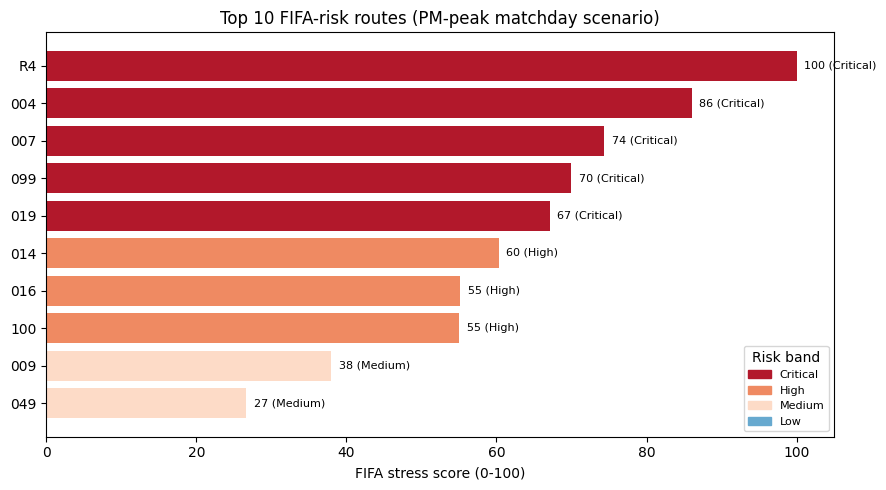

In [9]:
# --- CHART: Top 10 FIFA-risk routes ---
top10 = ranked.head(10).iloc[::-1]
colors = {"Critical":"#b2182b","High":"#ef8a62","Medium":"#fddbc7","Low":"#67a9cf"}
fig, ax = plt.subplots(figsize=(9,5))
ax.barh(top10["route_short_name"], top10["fifa_stress_score"],
        color=[colors.get(b,"#999") for b in top10["fifa_risk_band"]])
ax.set_xlabel("FIFA stress score (0-100)")
ax.set_title("Top 10 FIFA-risk routes (PM-peak matchday scenario)")
for i,(s,b) in enumerate(zip(top10["fifa_stress_score"], top10["fifa_risk_band"])):
    ax.text(s+1, i, f"{s:.0f} ({b})", va="center", fontsize=8)
handles = [plt.Rectangle((0,0),1,1,color=c) for c in colors.values()]
ax.legend(handles, colors.keys(), title="Risk band", loc="lower right", fontsize=8)
plt.tight_layout(); plt.show()


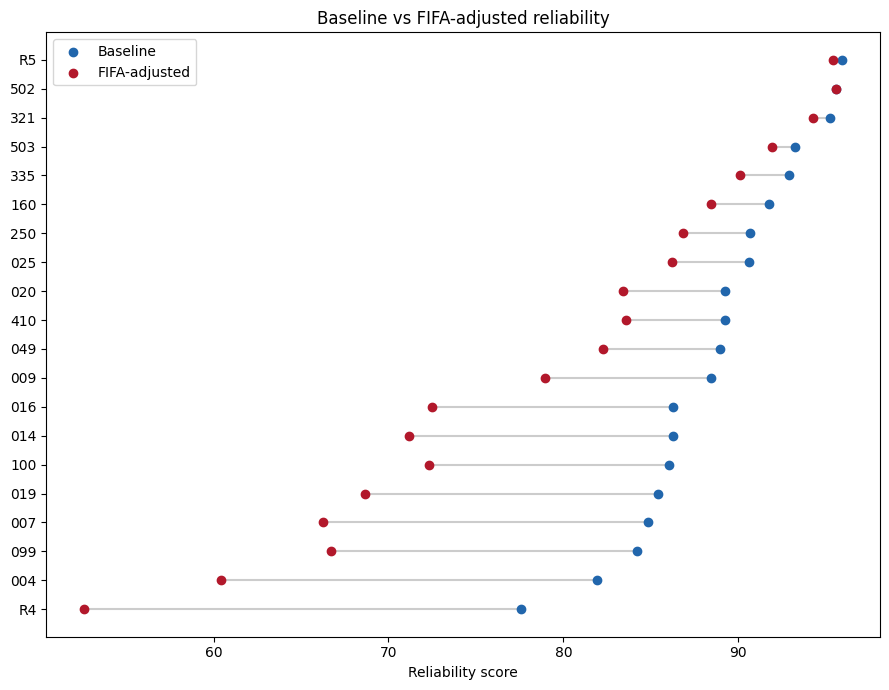

In [10]:
# --- CHART: Normal vs FIFA-adjusted reliability ---
o = ranked.sort_values("reliability_score", ascending=True)
y = np.arange(len(o))
fig, ax = plt.subplots(figsize=(9,7))
ax.hlines(y, o["fifa_adjusted_reliability"], o["reliability_score"], color="#cccccc", zorder=1)
ax.scatter(o["reliability_score"], y, color="#2166ac", label="Baseline", zorder=2)
ax.scatter(o["fifa_adjusted_reliability"], y, color="#b2182b", label="FIFA-adjusted", zorder=2)
ax.set_yticks(y); ax.set_yticklabels(o["route_short_name"])
ax.set_xlabel("Reliability score"); ax.set_title("Baseline vs FIFA-adjusted reliability")
ax.legend(); plt.tight_layout(); plt.show()


## 10. Identify top hotspot segments with stop names

We join the FIFA risk band back onto the bunching hotspots (which carry real stop
names). A hotspot on a Critical/High route is where FIFA-day monitoring should
physically focus — these are named street segments, not abstract scores.

In [11]:
hs = hotspots.copy()
hs["route_short_name"] = hs["route_short_name"].astype(str)
risk_lookup = ranked.set_index("route_short_name")[
    ["fifa_stress_score","fifa_risk_band","fifa_priority_rank"]]
hs = hs.merge(risk_lookup, on="route_short_name", how="left")

# hotspot risk = segment severity weighted by route-level FIFA stress
hs["hotspot_risk_score"] = (
    (hs["bunching_events"] + 3*hs["severe_events"]) * (hs["fifa_stress_score"]/100)
).round(2)

hot_rank = hs.sort_values("hotspot_risk_score", ascending=False).head(15)
show_cols = ["route_short_name","fifa_risk_band","stop_before_name","stop_after_name",
             "bunching_events","severe_events","median_gap_km","hotspot_risk_score"]
display(hot_rank[show_cols].reset_index(drop=True))


,route_short_name,fifa_risk_band,stop_before_name,stop_after_name,bunching_events,severe_events,median_gap_km,hotspot_risk_score
0,R4,Critical,Eastbound W 41 Ave @ Carnarvon St,Eastbound W 41 Ave @ Maple St,111,17,0.207,162.00
1,099,Critical,Eastbound W Broadway @ Heather St,Eastbound E Broadway @ Kingsway,86,33,0.139,129.39
2,R4,Critical,Eastbound W 41 Ave @ Carnarvon St,Eastbound W 41 Ave @ Granville St,86,4,0.253,98.00
3,099,Critical,Eastbound W Broadway @ Granville St,Broadway-City Hall Station @ Bay 1,92,13,0.181,91.62
4,R4,Critical,Westbound E 41 Ave @ Clarendon St,Westbound E 41 Ave @ Knight St,39,17,0.180,90.00
5,014,High,Southbound Granville St @ Drake St,Westbound W 4th Ave @ Fir St,77,24,0.209,89.82
6,004,Critical,Southbound Granville St @ Drake St,Westbound W 4th Ave @ Fir St,58,14,0.154,86.03
7,R4,Critical,Eastbound E 41 Ave @ Knight St,Eastbound E 41 Ave @ Clarendon St,40,14,0.153,82.00
8,019,Critical,Westbound Kingsway @ Boundary Rd,Westbound Kingsway @ Wessex St,71,16,0.216,79.84
9,R4,Critical,Westbound W 41 Ave @ Oak St,Westbound W 41 Ave @ East Blvd,32,15,0.132,77.00


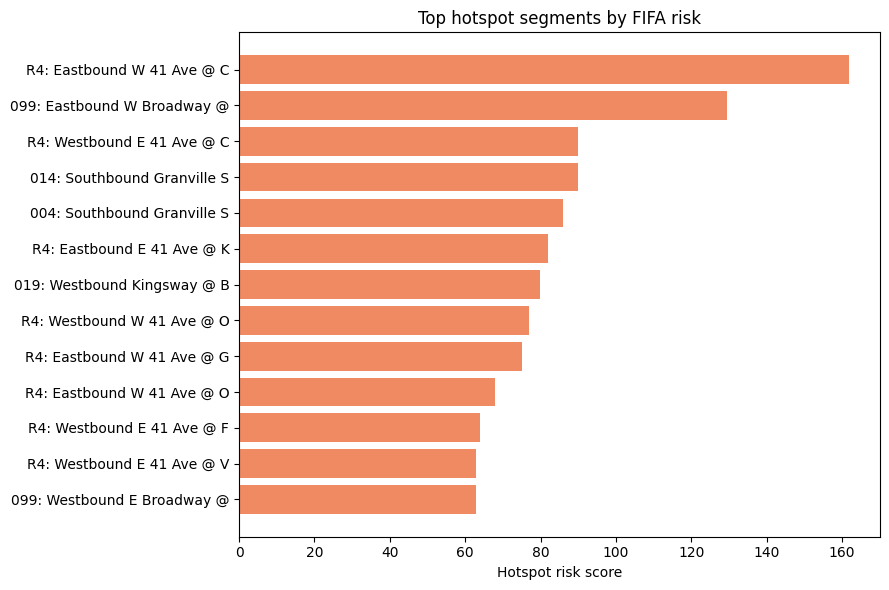

In [12]:
# --- CHART: hotspot risk by route ---
hr = hot_rank.copy()
hr["label"] = hr["route_short_name"] + ": " + hr["stop_before_name"].str.slice(0,22)
hr = hr.iloc[::-1]
fig, ax = plt.subplots(figsize=(9,6))
ax.barh(hr["label"], hr["hotspot_risk_score"], color="#ef8a62")
ax.set_xlabel("Hotspot risk score"); ax.set_title("Top hotspot segments by FIFA risk")
plt.tight_layout(); plt.show()


## 11. Compare route types

Do RapidBus / B-Line / Regular / Express corridors carry different FIFA risk? This
tells planners whether the exposure concentrates in trunk rapid services (which serve
downtown/venues) or spreads across regular routes.

,route_type,routes,avg_baseline_rel,avg_fifa_adj_rel,avg_stress,avg_drop
0,B-Line,1,84.21,66.72,69.94,17.49
1,RapidBus,2,86.77,74.02,50.99,12.75
2,Regular Bus,13,88.11,77.70,41.64,10.41
3,Express / Regional,4,92.83,90.70,8.50,2.12


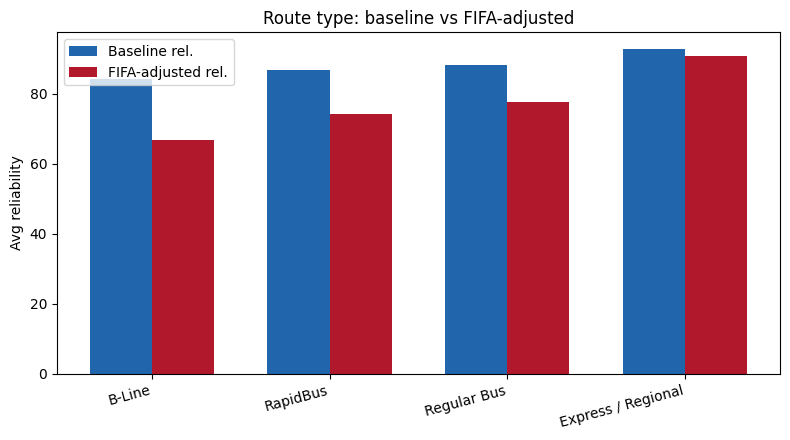

In [13]:
by_type = (ranked.groupby("route_type")
           .agg(routes=("route_short_name","count"),
                avg_baseline_rel=("reliability_score","mean"),
                avg_fifa_adj_rel=("fifa_adjusted_reliability","mean"),
                avg_stress=("fifa_stress_score","mean"),
                avg_drop=("reliability_drop","mean"))
           .round(2).sort_values("avg_stress", ascending=False).reset_index())
display(by_type)

fig, ax = plt.subplots(figsize=(8,4.5))
x = np.arange(len(by_type)); w=0.35
ax.bar(x-w/2, by_type["avg_baseline_rel"], w, label="Baseline rel.", color="#2166ac")
ax.bar(x+w/2, by_type["avg_fifa_adj_rel"], w, label="FIFA-adjusted rel.", color="#b2182b")
ax.set_xticks(x); ax.set_xticklabels(by_type["route_type"], rotation=15, ha="right")
ax.set_ylabel("Avg reliability"); ax.set_title("Route type: baseline vs FIFA-adjusted")
ax.legend(); plt.tight_layout(); plt.show()


## 12. Scenario comparison (4 scenarios)

The same routes under four worlds: **Normal**, **FIFA off-peak**, **FIFA PM-peak**,
**FIFA knockout**. Only the global `scenario_pressure` term changes; exposure and
fragility stay fixed. This isolates "how much does *when* the match happens matter?"
from "how exposed is the route?".

In [14]:
scenario_frames = []
for scen, pressure in FIFA["scenario_pressure"].items():
    tmp = df.copy()
    tmp["raw_stress"] = tmp.apply(lambda r: raw_stress(r, pressure), axis=1)
    tmp["fifa_stress_score"] = scale_0_100(tmp["raw_stress"]).round(2)
    tmp["scenario"] = scen
    scenario_frames.append(tmp[["route_short_name","route_type","scenario","fifa_stress_score"]])

scen_long = pd.concat(scenario_frames, ignore_index=True)
scen_wide = scen_long.pivot_table(index=["route_short_name","route_type"],
                                  columns="scenario", values="fifa_stress_score").reset_index()
scen_order = list(FIFA["scenario_pressure"].keys())
scen_wide = scen_wide[["route_short_name","route_type"]+scen_order]
scen_wide = scen_wide.sort_values("fifa_pmpeak_match", ascending=False)
display(scen_wide.round(1))


scenario,route_short_name,route_type,normal_day,fifa_offpeak_match,fifa_pmpeak_match,fifa_knockout_match
18,R4,RapidBus,100.0,100.0,100.0,100.0
0,004,Regular Bus,86.0,86.0,86.0,86.0
1,007,Regular Bus,74.3,74.3,74.3,74.3
9,099,B-Line,69.9,69.9,69.9,69.9
5,019,Regular Bus,67.1,67.1,67.1,67.1
3,014,Regular Bus,60.3,60.3,60.3,60.3
4,016,Regular Bus,55.2,55.2,55.2,55.2
10,100,Regular Bus,55.0,55.0,55.0,55.0
2,009,Regular Bus,38.0,38.0,38.0,38.0
8,049,Regular Bus,26.6,26.6,26.6,26.6


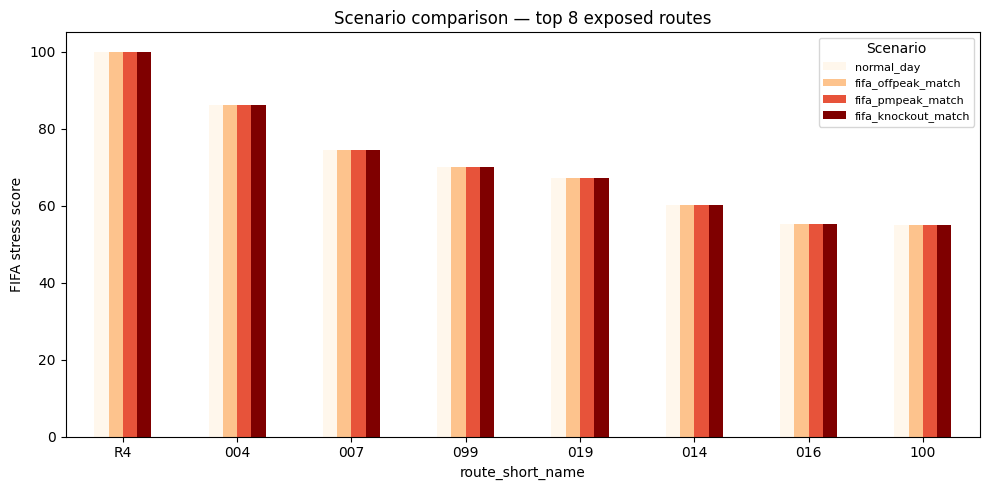

In [15]:
# --- CHART: scenario comparison for top 8 routes ---
top8 = scen_wide.head(8)["route_short_name"].tolist()
plot_df = scen_long[scen_long["route_short_name"].isin(top8)]
pivot = plot_df.pivot_table(index="route_short_name", columns="scenario",
                            values="fifa_stress_score")[scen_order].loc[top8]
fig, ax = plt.subplots(figsize=(10,5))
pivot.plot(kind="bar", ax=ax, colormap="OrRd")
ax.set_ylabel("FIFA stress score"); ax.set_title("Scenario comparison — top 8 exposed routes")
ax.legend(title="Scenario", fontsize=8); plt.xticks(rotation=0)
plt.tight_layout(); plt.show()


## 13. Build the ML-ready feature table

We assemble the engineered features the brief lists. Note `worst_segment_events`
comes straight from the corridor priority file; route_type is label-encoded.

This table is *derived from the scenario model*, so treat the ML that follows as a
**consistency check on our own scoring**, not an external oracle.

In [16]:
feat = df.copy()

# pull worst_segment_events from priority (already in df since df started as priority)
feat["worst_segment_events"] = feat.get("worst_segment_events", 0)

# encode route type
type_codes = {t:i for i,t in enumerate(sorted(feat["route_type"].unique()))}
feat["route_type_encoded"] = feat["route_type"].map(type_codes)

ML_FEATURES = [
    "reliability_score","bunching_rate_pct","severe_bunching_rate_pct",
    "peak_bunching_share_pct","total_bunching_events","severe_events",
    "intervention_priority_score","worst_segment_events",
    "bc_place_exposure","downtown_exposure","fan_festival_exposure",
    "skytrain_connector_exposure","pm_peak_vulnerability",
    "existing_reliability_weakness","route_type_encoded",
]
# some columns may be named differently across files; guard them
for c in ML_FEATURES:
    if c not in feat.columns:
        print(f"[warn] feature missing, filling 0: {c}")
        feat[c] = 0

ml_table = feat[["route_short_name","route_type","fifa_stress_score"]+ML_FEATURES].copy()
print("Route type encoding:", type_codes)
display(ml_table.head())


Route type encoding: {'B-Line': 0, 'Express / Regional': 1, 'RapidBus': 2, 'Regular Bus': 3}


,route_short_name,route_type,fifa_stress_score,reliability_score,bunching_rate_pct,severe_bunching_rate_pct,peak_bunching_share_pct,total_bunching_events,severe_events,intervention_priority_score,worst_segment_events,bc_place_exposure,downtown_exposure,fan_festival_exposure,skytrain_connector_exposure,pm_peak_vulnerability,existing_reliability_weakness,route_type_encoded
0,R4,RapidBus,100.00,77.60,12.03,2.14,36.89,1301,232,52.42,111,1,0,0,0,0,1,2
1,004,Regular Bus,86.03,81.95,7.45,0.94,72.29,776,98,34.94,58,1,1,0,0,1,1,3
2,099,B-Line,69.94,84.21,7.36,0.81,53.40,1000,110,33.86,92,1,1,0,0,0,1,0
3,019,Regular Bus,67.09,85.41,6.97,1.16,39.07,1208,202,32.08,71,1,1,0,0,0,1,3
4,016,Regular Bus,55.17,86.29,6.39,0.66,47.27,1263,131,29.02,75,1,0,0,1,0,1,3


## 14. Create the transparent ML target label

The label is defined by a **published threshold** on our scenario stress score —
nothing hidden. A route is `fifa_high_risk = 1` if its stress score clears
`ml_high_risk_threshold`. We also keep the 4-level band as a multi-class option.

Because the label comes from our own formula, a perfect classifier would only prove
the formula is learnable from its inputs — which we expect. The value is in *which*
features the models lean on.

In [17]:
thr = FIFA["ml_high_risk_threshold"]
ml_table["fifa_high_risk"] = (ml_table["fifa_stress_score"] >= thr).astype(int)
ml_table["fifa_risk_band"] = ml_table["fifa_stress_score"].apply(band)

print(f"High-risk threshold: {thr}")
print(ml_table["fifa_high_risk"].value_counts().rename({0:"not-high",1:"high"}))
print("\nBand distribution:")
print(ml_table["fifa_risk_band"].value_counts())


High-risk threshold: 45.0
fifa_high_risk
not-high    12
high         8
Name: count, dtype: int64

Band distribution:
fifa_risk_band
Low         10
Critical     5
High         3
Medium       2
Name: count, dtype: int64


## 15–17. Train and cautiously evaluate models

With only **20 routes**, this is a *prototype*. We:

- use **Leave-One-Out cross-validation** (LOOCV) instead of a single split — with 20
  rows a random test split is meaningless.
- report accuracy/ROC-AUC **with loud caveats**.
- treat the models as *explainers*, not deployable classifiers.

Models: Logistic Regression (coefficients = direction of influence) and Random Forest
(impurity importance = magnitude of influence).

In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import LeaveOneOut, cross_val_predict
from sklearn.metrics import (accuracy_score, classification_report,
                             roc_auc_score, r2_score, mean_absolute_error)

X = ml_table[ML_FEATURES].values
y = ml_table["fifa_high_risk"].values

n_pos, n_neg = int(y.sum()), int((1-y).sum())
print(f"Samples: {len(y)}  high-risk: {n_pos}  not-high: {n_neg}")

loo = LeaveOneOut()

# ----- Logistic Regression (scaled) -----
scaler = StandardScaler()
Xs = scaler.fit_transform(X)
logit = LogisticRegression(max_iter=1000, class_weight="balanced")

if n_pos >= 2 and n_neg >= 2:
    logit_pred = cross_val_predict(logit, Xs, y, cv=loo)
    print(f"\nLogReg LOOCV accuracy: {accuracy_score(y, logit_pred):.2f}")
    print(classification_report(y, logit_pred, zero_division=0))
else:
    print("\n[skip] too few per class for LOOCV; fitting on full data for explanation only.")
    logit_pred = None

logit.fit(Xs, y)   # full-fit for coefficients


Samples: 20  high-risk: 8  not-high: 12

LogReg LOOCV accuracy: 0.90
              precision    recall  f1-score   support

           0       0.92      0.92      0.92        12
           1       0.88      0.88      0.88         8

    accuracy                           0.90        20
   macro avg       0.90      0.90      0.90        20
weighted avg       0.90      0.90      0.90        20



,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

In [19]:
# ----- Random Forest classifier -----
rf = RandomForestClassifier(n_estimators=300, random_state=42,
                            class_weight="balanced", max_depth=4)
if n_pos >= 2 and n_neg >= 2:
    rf_pred = cross_val_predict(rf, X, y, cv=loo)
    print(f"RandomForest LOOCV accuracy: {accuracy_score(y, rf_pred):.2f}")
    print(classification_report(y, rf_pred, zero_division=0))
else:
    rf_pred = None
    print("[skip] too few per class for LOOCV classification.")
rf.fit(X, y)


RandomForest LOOCV accuracy: 0.95
              precision    recall  f1-score   support

           0       0.92      1.00      0.96        12
           1       1.00      0.88      0.93         8

    accuracy                           0.95        20
   macro avg       0.96      0.94      0.95        20
weighted avg       0.95      0.95      0.95        20



,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",4
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_

In [20]:
# ----- Optional: Random Forest REGRESSOR on the continuous stress score -----
yr = ml_table["fifa_stress_score"].values
rfr = RandomForestRegressor(n_estimators=300, random_state=42, max_depth=4)
rfr_pred = cross_val_predict(rfr, X, yr, cv=loo)
print("RF regressor (predicting stress score) — LOOCV:")
print(f"  R2  : {r2_score(yr, rfr_pred):.2f}")
print(f"  MAE : {mean_absolute_error(yr, rfr_pred):.2f} stress points")
rfr.fit(X, yr)
print("\nNOTE: high R2 here mostly confirms the score is a learnable function of its"
      "\nown inputs — it is NOT evidence of real-world FIFA predictive accuracy.")


RF regressor (predicting stress score) — LOOCV:
  R2  : 0.90
  MAE : 6.98 stress points



NOTE: high R2 here mostly confirms the score is a learnable function of its
own inputs — it is NOT evidence of real-world FIFA predictive accuracy.


> **Reading the metrics honestly.** With 20 routes and a label we defined, strong
> scores are *expected and not impressive*. Weak scores would actually be more
> interesting (they'd mean the scenario formula is doing something the features can't
> reproduce). Use these models for the **feature story** below, not for bragging
> rights on accuracy.

## 18. Feature importance

Two complementary views: Random Forest impurity importance (magnitude) and Logistic
Regression standardized coefficients (direction).

,feature,rf_importance,logit_coef
0,reliability_score,0.1964,-0.4568
1,intervention_priority_score,0.1501,0.4821
2,worst_segment_events,0.1244,0.5820
3,bc_place_exposure,0.1114,0.6099
4,severe_bunching_rate_pct,0.0905,0.4499
5,bunching_rate_pct,0.0881,0.4430
6,total_bunching_events,0.0747,0.3395
7,severe_events,0.0703,0.2996
8,existing_reliability_weakness,0.0675,0.4334
9,downtown_exposure,0.0128,0.4474


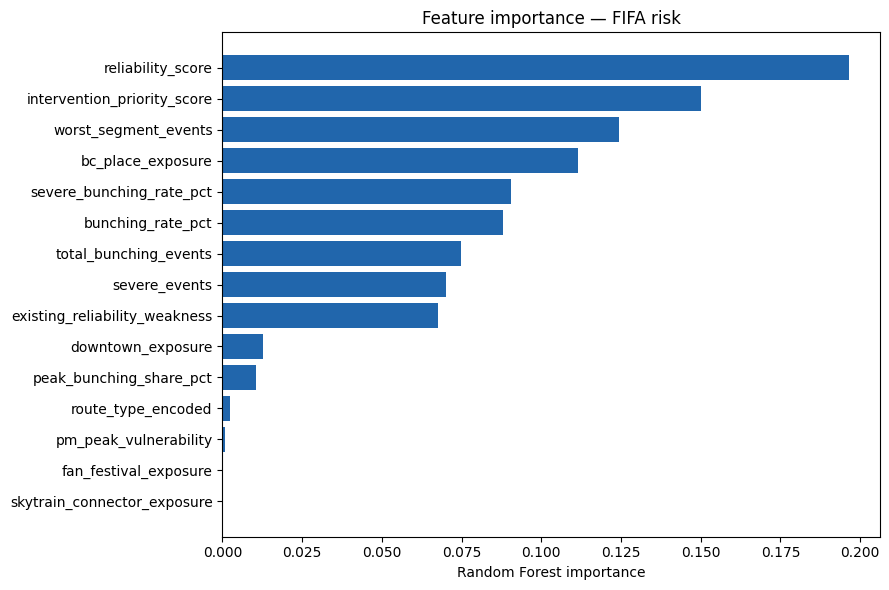

In [21]:
imp = pd.DataFrame({
    "feature": ML_FEATURES,
    "rf_importance": rf.feature_importances_,
    "logit_coef": logit.coef_[0],
}).sort_values("rf_importance", ascending=False).reset_index(drop=True)
display(imp.round(4))

fig, ax = plt.subplots(figsize=(9,6))
d = imp.iloc[::-1]
ax.barh(d["feature"], d["rf_importance"], color="#2166ac")
ax.set_xlabel("Random Forest importance"); ax.set_title("Feature importance — FIFA risk")
plt.tight_layout(); plt.show()


## 19. Compare scenario ranking vs ML risk classification

The key validation step: where do the deterministic scenario score and the ML
classifier **agree**, and where do they **disagree**? Disagreements are the routes
worth a human second look — they're where a non-linear model sees something the
linear scoring smooths over.

,route_short_name,route_type,fifa_stress_score,fifa_high_risk,fifa_risk_band,rf_prob_high,rf_pred_high,agreement
0,R4,RapidBus,100.00,1,Critical,0.983,1,agree
1,004,Regular Bus,86.03,1,Critical,0.993,1,agree
2,007,Regular Bus,74.33,1,Critical,0.983,1,agree
3,099,B-Line,69.94,1,Critical,0.990,1,agree
4,019,Regular Bus,67.09,1,Critical,0.997,1,agree
5,014,Regular Bus,60.28,1,High,0.970,1,agree
6,016,Regular Bus,55.17,1,High,0.983,1,agree
7,100,Regular Bus,55.05,1,High,0.823,1,agree
8,009,Regular Bus,38.00,0,Medium,0.100,0,agree
9,049,Regular Bus,26.64,0,Medium,0.037,0,agree


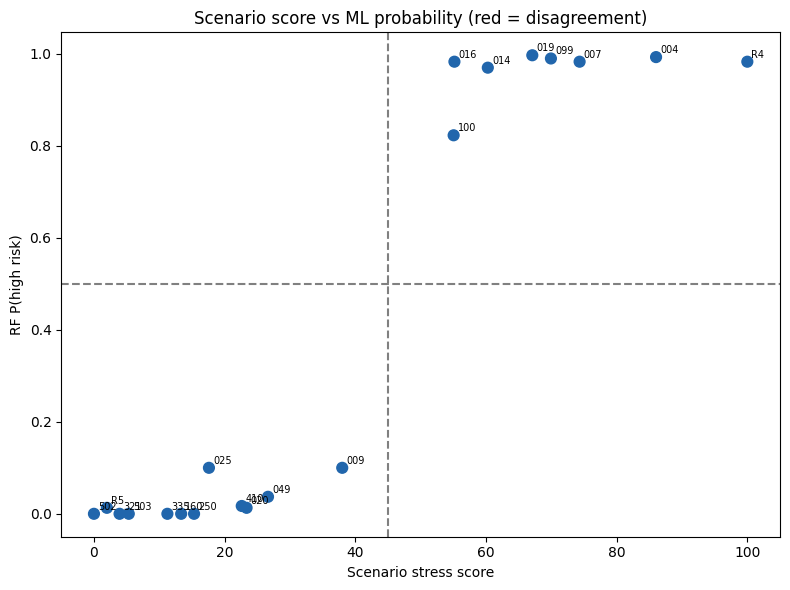

In [22]:
compare = ml_table[["route_short_name","route_type","fifa_stress_score",
                     "fifa_high_risk","fifa_risk_band"]].copy()
# RF predicted probability of high risk (full-fit, for ranking only)
compare["rf_prob_high"] = rf.predict_proba(X)[:,1].round(3)
compare["rf_pred_high"] = rf.predict(X)
compare["agreement"] = np.where(compare["fifa_high_risk"]==compare["rf_pred_high"],
                                "agree","DISAGREE")
compare = compare.sort_values("fifa_stress_score", ascending=False).reset_index(drop=True)
display(compare)

fig, ax = plt.subplots(figsize=(8,6))
col = compare["agreement"].map({"agree":"#2166ac","DISAGREE":"#b2182b"})
ax.scatter(compare["fifa_stress_score"], compare["rf_prob_high"], c=col, s=60)
for _,r in compare.iterrows():
    ax.annotate(r["route_short_name"], (r["fifa_stress_score"], r["rf_prob_high"]),
                fontsize=7, xytext=(3,3), textcoords="offset points")
ax.axhline(0.5, ls="--", color="grey"); ax.axvline(thr, ls="--", color="grey")
ax.set_xlabel("Scenario stress score"); ax.set_ylabel("RF P(high risk)")
ax.set_title("Scenario score vs ML probability (red = disagreement)")
plt.tight_layout(); plt.show()


## 20. Export outputs

All eight required CSVs, written to `fifa_outputs/`.

In [23]:
# 1. route stress scores
ranked.to_csv(OUT_DIR/"fifa_route_stress_scores.csv", index=False)

# 2. corridor risk ranking (lean operational view)
ranked[["fifa_priority_rank","route_short_name","route_long_name","route_type",
        "reliability_score","fifa_adjusted_reliability","reliability_drop",
        "fifa_stress_score","fifa_risk_band","has_extra_service"]
      ].to_csv(OUT_DIR/"fifa_corridor_risk_ranking.csv", index=False)

# 3. hotspot risk summary
hot_rank.to_csv(OUT_DIR/"fifa_hotspot_risk_summary.csv", index=False)

# 4. scenario comparison
scen_wide.to_csv(OUT_DIR/"fifa_scenario_comparison.csv", index=False)

# 5. ML feature table
ml_table.to_csv(OUT_DIR/"fifa_ml_feature_table.csv", index=False)

# 6. ML route predictions
compare.to_csv(OUT_DIR/"fifa_ml_route_predictions.csv", index=False)

# 7. feature importance
imp.to_csv(OUT_DIR/"fifa_feature_importance.csv", index=False)

# 8. model summary
model_summary = pd.DataFrame([
    {"model":"LogisticRegression","task":"classify high-risk",
     "cv":"LOOCV",
     "accuracy": round(accuracy_score(y, logit_pred),3) if logit_pred is not None else None,
     "notes":"explainability / coefficient direction"},
    {"model":"RandomForestClassifier","task":"classify high-risk","cv":"LOOCV",
     "accuracy": round(accuracy_score(y, rf_pred),3) if rf_pred is not None else None,
     "notes":"feature importance"},
    {"model":"RandomForestRegressor","task":"estimate stress score","cv":"LOOCV",
     "accuracy": round(r2_score(yr, rfr_pred),3),
     "notes":"R2; sensitivity only, NOT real forecast"},
])
model_summary.to_csv(OUT_DIR/"fifa_model_summary.csv", index=False)

print("Exported 8 CSVs to", OUT_DIR.resolve())
for f in sorted(OUT_DIR.glob("*.csv")):
    print("  ", f.name)


Exported 8 CSVs to /home/claude/fifa_outputs
   fifa_corridor_risk_ranking.csv
   fifa_feature_importance.csv
   fifa_hotspot_risk_summary.csv
   fifa_ml_feature_table.csv
   fifa_ml_route_predictions.csv
   fifa_model_summary.csv
   fifa_route_stress_scores.csv
   fifa_scenario_comparison.csv


## 21. Executive summary (auto-generated template)

The cell below fills a template from the computed results so the summary always
matches the current config.

In [24]:
crit = ranked[ranked["fifa_risk_band"].isin(["Critical","High"])]
already_weak = ranked[ranked["existing_reliability_weakness"]==1]
top3 = ranked.head(3)["route_short_name"].tolist()
fest = ranked[ranked["fan_festival_exposure"]==1]["route_short_name"].tolist()
not_monitored = [r for r in FIFA["extra_service_routes"]
                 if r not in ranked["route_short_name"].astype(str).tolist()]

summary = f'''
EXECUTIVE SUMMARY — FIFA 2026 Vancouver Transit Stress Simulation
=================================================================
Scenario basis : PM-peak matchday (primary).  Prototype, scenario-based.
Routes analysed: {len(ranked)} highest-activity corridors.

HEADLINE
- Highest FIFA operational risk: {", ".join(top3)}.
- {len(crit)} of {len(ranked)} corridors fall in High/Critical risk bands under the
  PM-peak matchday scenario.
- {len(already_weak)} corridors are ALREADY below median reliability before any FIFA
  load — FIFA compounds existing weakness rather than creating it.

VENUE / FESTIVAL EXPOSURE
- Fan-Festival-exposed corridors in scope: {", ".join(fest) if fest else "none tagged"}.
- TransLink extra-service routes NOT in the current Top-20 monitored set:
  {", ".join(not_monitored) if not_monitored else "all are monitored"}.
  -> recommend extending monitoring to these before the tournament.

WHAT DRIVES THE RISK (from ML feature importance)
- Top features: {", ".join(imp.head(3)["feature"].tolist())}.
- This is consistent with the scenario design: existing fragility + venue/peak
  exposure dominate.

RECOMMENDED ACTIONS
1. Prioritise real-time monitoring on: {", ".join(top3)}.
2. Pre-position supervision at the named hotspot segments (see hotspot summary).
3. Validate exposure tags with local network planners before operational use.
4. Extend telemetry coverage to extra-service routes outside the Top 20.
'''
print(summary)
(OUT_DIR/"fifa_executive_summary.txt").write_text(summary)
print("Saved fifa_executive_summary.txt")



EXECUTIVE SUMMARY — FIFA 2026 Vancouver Transit Stress Simulation
Scenario basis : PM-peak matchday (primary).  Prototype, scenario-based.
Routes analysed: 20 highest-activity corridors.

HEADLINE
- Highest FIFA operational risk: R4, 004, 007.
- 8 of 20 corridors fall in High/Critical risk bands under the
  PM-peak matchday scenario.
- 10 corridors are ALREADY below median reliability before any FIFA
  load — FIFA compounds existing weakness rather than creating it.

VENUE / FESTIVAL EXPOSURE
- Fan-Festival-exposed corridors in scope: 014, R5.
- TransLink extra-service routes NOT in the current Top-20 monitored set:
  028, 130, 222.
  -> recommend extending monitoring to these before the tournament.

WHAT DRIVES THE RISK (from ML feature importance)
- Top features: reliability_score, intervention_priority_score, worst_segment_events.
- This is consistent with the scenario design: existing fragility + venue/peak
  exposure dominate.

RECOMMENDED ACTIONS
1. Prioritise real-time monitori

## 22. Limitations and future improvements

**This is a prototype scenario model, not a forecast.** Specific limitations:

- **No real demand data.** FIFA ridership, passenger counts, and crowd movement are
  not in the inputs. Stress is inferred from *existing* reliability behavior plus
  *assumed* exposure, not measured FIFA load.
- **Exposure tags are hand-assigned.** BC Place / downtown / Fan Festival flags rely
  on route knowledge and must be reviewed by local planners. Geometry-based tagging
  (does the shape pass within X m of BC Place / PNE?) would be a real improvement.
- **Weights are planning assumptions.** Every multiplier in the `FIFA` config is a
  judgement call. Run sensitivity analysis by varying them.
- **ML is trained on our own labels.** It validates internal consistency and surfaces
  feature importance — it does **not** independently confirm real-world risk. High
  accuracy is expected and not meaningful as forecast skill.
- **Tiny sample (20 routes).** LOOCV mitigates but cannot eliminate this. Treat model
  outputs as directional.
- **Single service date baseline.** The reliability inputs reflect one day; multi-day
  baselines would stabilize the fragility estimates.

**To turn this into a real forecast you would need:** actual FIFA-matchday AVL
telemetry, automated passenger counts (APC), fare-tap origin-destination data,
planned service-change schedules, and event-day crowd-flow estimates — then retrain
against *observed* matchday degradation rather than a self-defined label.